# Segmentasi Pelanggan dengan Clustering

**Tujuan:** mengelompokkan pelanggan sebuah perusahaan retail berdasarkan profil dan perilaku belanja, lalu menerjemahkan tiap kelompok menjadi persona dan rekomendasi marketing.

**Dataset:** *Customer Personality Analysis* (Kaggle) — 2.240 pelanggan, 29 kolom, periode pendaftaran 2012–2014.

**Alur:**
1. Load data
2. Data cleaning
3. Feature engineering
4. EDA
5. Preprocessing
6. Skenario model (K-Means, Agglomerative, GMM, DBSCAN × data scaled / PCA)
7. Pemilihan model & uji stabilitas
8. Profiling cluster
9. Persona & rekomendasi
10. Kesimpulan

## 1. Load Data

In [1]:
import os
import warnings
import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
path = kagglehub.dataset_download("vishakhdapat/customer-segmentation-clustering")
df = pd.read_csv(os.path.join(path, "customer_segmentation.csv"))
print(df.shape)
df.head()

100%|██████████| 62.0k/62.0k [00:00<00:00, 3.25MB/s]

Extracting files...
(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Kolom dikelompokkan menjadi 4 bagian:

| Kelompok | Kolom |
|---|---|
| Profil | `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome`, `Dt_Customer`, `Recency`, `Complain` |
| Produk (belanja 2 tahun terakhir) | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` |
| Promosi | `AcceptedCmp1`–`AcceptedCmp5`, `Response`, `NumDealsPurchases` |
| Channel | `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumWebVisitsMonth` |

## 2. Data Cleaning

In [3]:
print("Missing values:")
print(df.isna().sum()[lambda s: s > 0])
print("\nDuplikat:", df.duplicated().sum())
print("\nKolom konstan:", [c for c in df.columns if df[c].nunique() == 1])

Missing values:
Income    24
dtype: int64

Duplikat: 0

Kolom konstan: ['Z_CostContact', 'Z_Revenue']


- Hanya `Income` yang kosong (24 baris, ~1%) → baris dihapus.
- Tidak ada duplikat.
- `Z_CostContact` dan `Z_Revenue` bernilai konstan → dihapus karena tidak memberi informasi.
- `Dt_Customer` masih string berformat `dd-mm-yyyy` → diubah ke datetime dengan `dayfirst=True`.

In [4]:
df = df.dropna(subset=["Income"])
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
print(df.shape)
print("Rentang tanggal daftar:", df["Dt_Customer"].min().date(), "s/d", df["Dt_Customer"].max().date())

(2216, 27)
Rentang tanggal daftar: 2012-07-30 s/d 2014-06-29


In [5]:
print(df["Marital_Status"].value_counts(), "\n")
print(df["Education"].value_counts(), "\n")
print(df[["Year_Birth", "Income"]].describe().loc[["min", "50%", "max"]])

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64 

     Year_Birth    Income
min      1893.0    1730.0
50%      1970.0   51381.5
max      1996.0  666666.0


Anomali yang ditemukan:
- `Year_Birth` < 1901 (umur > 110 tahun) → kemungkinan salah input.
- `Income` = 666.666 → jauh di atas pelanggan lain (median ~51 ribu), kemungkinan nilai palsu.
- `Marital_Status` berisi `Alone`, `Absurd`, `YOLO` → akan digabung ke kategori *Alone* saat feature engineering.

Baris dengan umur tidak wajar dan income ekstrem dihapus (hanya 4 baris), karena nilainya jelas bukan data asli dan akan merusak scaling.

In [6]:
df = df[(df["Year_Birth"] > 1900) & (df["Income"] < 200_000)]
print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 2212


## 3. Feature Engineering

Fitur baru dibuat supaya profil pelanggan lebih mudah dibaca. Tanggal acuan = tanggal pendaftaran terakhir di data (bukan tanggal hari ini), supaya hasil tetap sama kapan pun notebook dijalankan.

In [7]:
ref_date = df["Dt_Customer"].max()
products = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
channels = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
campaigns = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]

df["Age"] = ref_date.year - df["Year_Birth"]
df["Customer_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Spent"] = df[products].sum(axis=1)
df["Purchases"] = df[channels].sum(axis=1)
df["Children"] = df["Kidhome"] + df["Teenhome"]
df["Is_Parent"] = (df["Children"] > 0).astype(int)
df["Living_With"] = df["Marital_Status"].map({"Married": "Partner", "Together": "Partner"}).fillna("Alone")
df["Family_Size"] = df["Living_With"].map({"Alone": 1, "Partner": 2}) + df["Children"]
df["Education"] = df["Education"].replace({"Basic": "Undergraduate", "2n Cycle": "Undergraduate",
                                           "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate"})
df["Total_Promos"] = df[campaigns].sum(axis=1)

df[["Age", "Customer_Days", "Spent", "Purchases", "Children", "Family_Size", "Total_Promos"]].describe().round(1)

,Age,Customer_Days,Spent,Purchases,Children,Family_Size,Total_Promos
count,2212.0,2212.0,2212.0,2212.0,2212.0,2212.0,2212.0
mean,45.1,353.7,607.3,12.6,0.9,2.6,0.3
std,11.7,202.5,602.5,7.2,0.7,0.9,0.7
min,18.0,0.0,5.0,0.0,0.0,1.0,0.0
25%,37.0,180.0,69.0,6.0,0.0,2.0,0.0
50%,44.0,356.0,397.0,12.0,1.0,3.0,0.0
75%,55.0,529.0,1048.0,18.2,1.0,3.0,0.0
max,74.0,699.0,2525.0,32.0,3.0,5.0,4.0


| Fitur | Keterangan |
|---|---|
| `Age` | Umur saat data diambil (2014) |
| `Customer_Days` | Lama menjadi pelanggan (hari) |
| `Spent` | Total belanja semua kategori produk |
| `Purchases` | Total transaksi (web + katalog + toko) |
| `Children`, `Is_Parent` | Jumlah anak / punya anak atau tidak |
| `Living_With`, `Family_Size` | Tinggal dengan pasangan atau sendiri / jumlah anggota keluarga |
| `Education` | Diringkas jadi 3 level |
| `Total_Promos` | Jumlah kampanye 1–5 yang diterima |

## 4. Exploratory Data Analysis

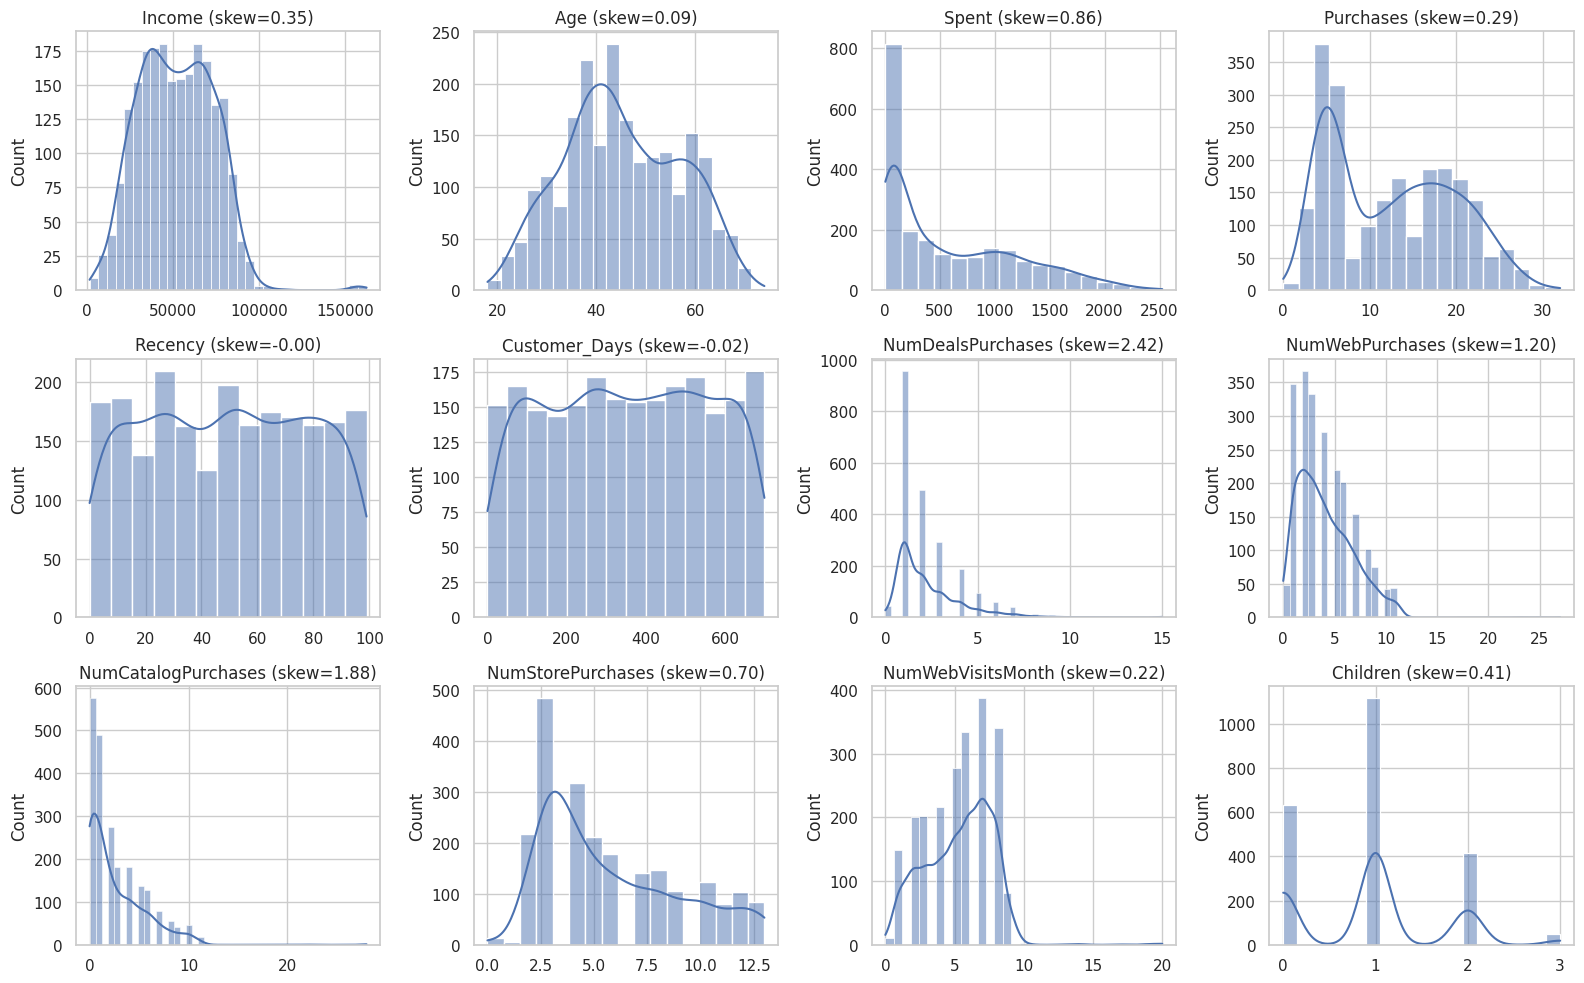

In [8]:
num_cols = ["Income", "Age", "Spent", "Purchases", "Recency", "Customer_Days",
            "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Children"]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

- `Income` dan `Age` cukup mendekati normal setelah anomali dibuang.
- `Spent` dan jumlah pembelian per channel **right-skewed**: mayoritas belanja sedikit, sebagian kecil belanja sangat banyak. `NumDealsPurchases` paling skewed.
- `Recency` dan `Customer_Days` tersebar hampir merata → kurang membedakan karakter pelanggan.

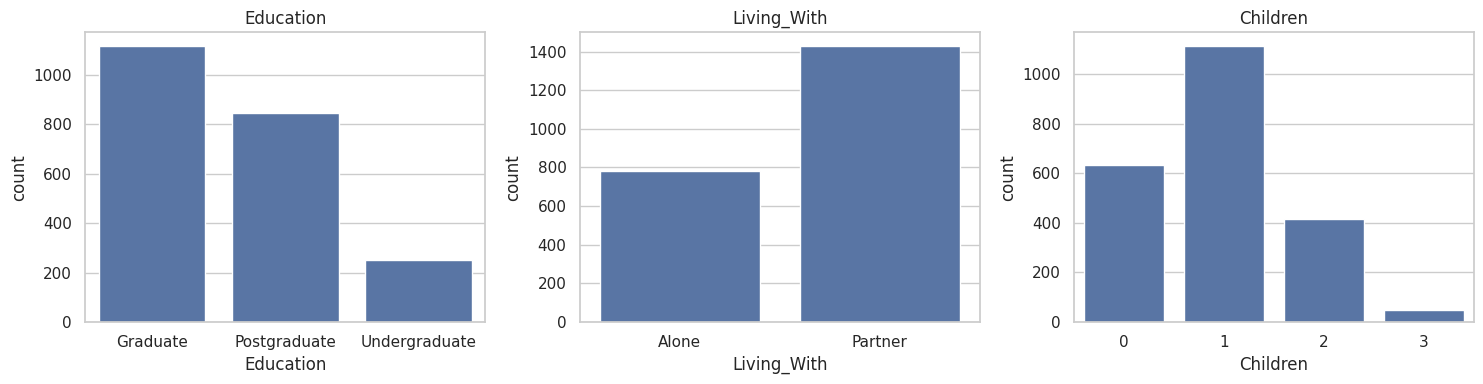

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Education", "Living_With", "Children"]):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- Mayoritas pelanggan lulusan S1 (*Graduate*) dan tinggal bersama pasangan.
- Sekitar 70% pelanggan punya minimal 1 anak.

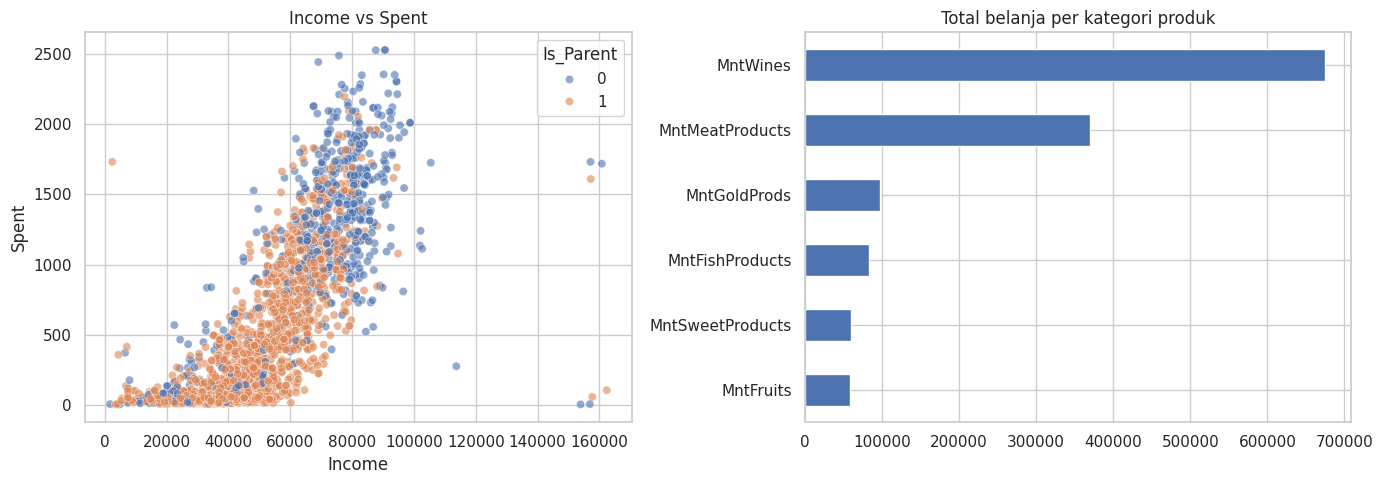

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Income", y="Spent", hue="Is_Parent", alpha=0.6, ax=axes[0])
axes[0].set_title("Income vs Spent")
df[products].sum().sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Total belanja per kategori produk")
plt.tight_layout()
plt.show()

- Hubungan `Income` dan `Spent` jelas positif: makin tinggi pendapatan, makin besar belanja.
- Pelanggan **tanpa anak** cenderung berada di area belanja tinggi.
- Wine dan daging mendominasi total penjualan.

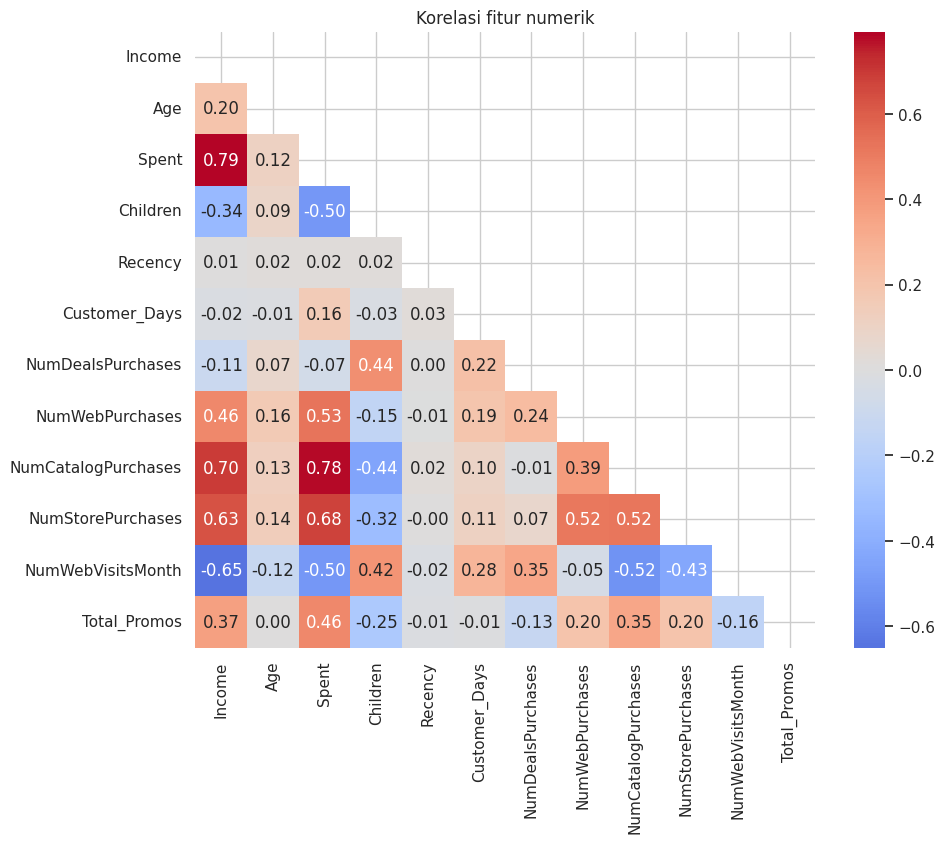

In [11]:
corr_cols = ["Income", "Age", "Spent", "Children", "Recency", "Customer_Days", "NumDealsPurchases",
             "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Total_Promos"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=np.triu(np.ones((len(corr_cols),) * 2, dtype=bool)))
plt.title("Korelasi fitur numerik")
plt.show()

- `Income`, `Spent`, pembelian katalog, dan pembelian di toko saling berkorelasi kuat (> 0.6) → mencerminkan satu dimensi "daya beli".
- `Children` berkorelasi negatif dengan `Spent`, tetapi positif dengan `NumDealsPurchases` dan `NumWebVisitsMonth` → keluarga dengan anak lebih sensitif harga.
- `Recency` dan `Customer_Days` hampir tidak berkorelasi dengan fitur lain.

## 5. Preprocessing

**Pemilihan fitur.** Fitur yang dipakai menggambarkan *siapa* pelanggan (income, umur, anak) dan *bagaimana* mereka belanja (total belanja, diskon, channel, kunjungan web).

Fitur yang **tidak** dipakai:
- `Recency` dan `Customer_Days`: tersebar merata dan tidak berkorelasi dengan fitur lain, sehingga hanya memecah cluster berdasarkan waktu, bukan karakter pelanggan.
- Kolom kampanye (`AcceptedCmp*`, `Response`) dan `Complain`: dipakai untuk *evaluasi* cluster, bukan pembentuknya.
- Kolom kategorikal (`Education`, `Living_With`): dipakai untuk profiling saja karena jarak Euclidean kurang cocok untuk data kategorikal.

**Transformasi.** Fitur yang skew-nya tinggi di-*log transform* (`log1p`) lalu semua fitur di-*standardize*, supaya tidak ada fitur yang mendominasi jarak.

In [12]:
features = ["Income", "Age", "Spent", "Children", "NumDealsPurchases",
            "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"]
log_cols = ["Spent", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases"]

X = df[features].copy()
X[log_cols] = np.log1p(X[log_cols])
print("Skew sebelum:", df[log_cols].skew().round(2).to_dict())
print("Skew sesudah:", X[log_cols].skew().round(2).to_dict())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Skew sebelum: {'Spent': 0.86, 'NumDealsPurchases': 2.42, 'NumWebPurchases': 1.2, 'NumCatalogPurchases': 1.88}
Skew sesudah: {'Spent': -0.38, 'NumDealsPurchases': 0.67, 'NumWebPurchases': -0.28, 'NumCatalogPurchases': 0.13}


**PCA.** Karena banyak fitur saling berkorelasi, PCA dipakai sebagai skenario kedua. Jumlah komponen dipilih yang menjelaskan minimal 80% variansi.

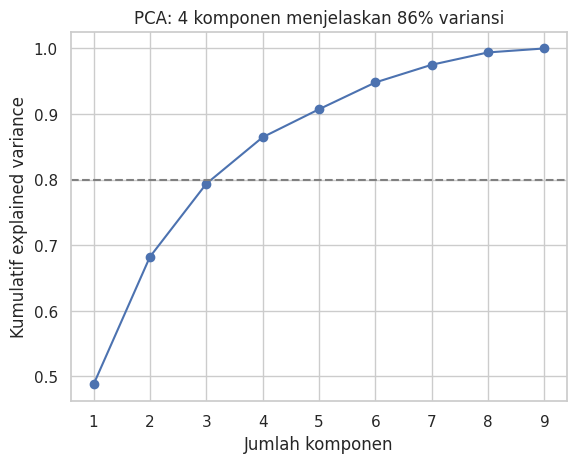

In [13]:
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cum_var >= 0.8) + 1)

plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.8, ls="--", c="gray")
plt.xlabel("Jumlah komponen"); plt.ylabel("Kumulatif explained variance")
plt.title(f"PCA: {n_comp} komponen menjelaskan {cum_var[n_comp - 1]:.0%} variansi")
plt.show()

pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

## 6. Skenario Model

Setiap kombinasi diuji untuk K = 2 sampai 8:

| Data | Model |
|---|---|
| Scaled (semua fitur) | K-Means, Agglomerative (Ward), Gaussian Mixture |
| PCA | K-Means, Agglomerative (Ward), Gaussian Mixture |

DBSCAN diuji terpisah karena tidak memakai parameter K.

**Metrik evaluasi:**
- **Silhouette** (−1 s/d 1, makin tinggi makin baik): seberapa rapat anggota cluster dan seberapa jauh dari cluster lain.
- **Calinski-Harabasz** (makin tinggi makin baik): rasio sebaran antar-cluster terhadap dalam-cluster.
- **Davies-Bouldin** (makin rendah makin baik): rata-rata kemiripan tiap cluster dengan cluster terdekatnya.

In [14]:
datasets = {"Scaled": X_scaled, "PCA": X_pca}
models = {
    "KMeans": lambda k: KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE),
    "Agglomerative": lambda k: AgglomerativeClustering(n_clusters=k, linkage="ward"),
    "GMM": lambda k: GaussianMixture(n_components=k, n_init=5, random_state=RANDOM_STATE),
}

results = []
for data_name, data in datasets.items():
    for model_name, make_model in models.items():
        for k in range(2, 9):
            labels = make_model(k).fit_predict(data)
            results.append({
                "Data": data_name, "Model": model_name, "K": k,
                "Silhouette": silhouette_score(data, labels),
                "Calinski_Harabasz": calinski_harabasz_score(data, labels),
                "Davies_Bouldin": davies_bouldin_score(data, labels),
                "Cluster_Terkecil": np.bincount(labels).min(),
            })

results = pd.DataFrame(results)
results.round(3)

,Data,Model,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Cluster_Terkecil
0,Scaled,KMeans,2,0.342,1390.668,1.183,1026
1,Scaled,KMeans,3,0.294,1171.077,1.312,646
2,Scaled,KMeans,4,0.235,927.118,1.532,355
3,Scaled,KMeans,5,0.202,802.857,1.703,334
4,Scaled,KMeans,6,0.196,722.001,1.684,296
5,Scaled,KMeans,7,0.204,661.377,1.542,233
6,Scaled,KMeans,8,0.187,610.781,1.572,232
7,Scaled,Agglomerative,2,0.321,1246.923,1.225,953
8,Scaled,Agglomerative,3,0.270,1059.339,1.364,597
9,Scaled,Agglomerative,4,0.202,824.511,1.579,270


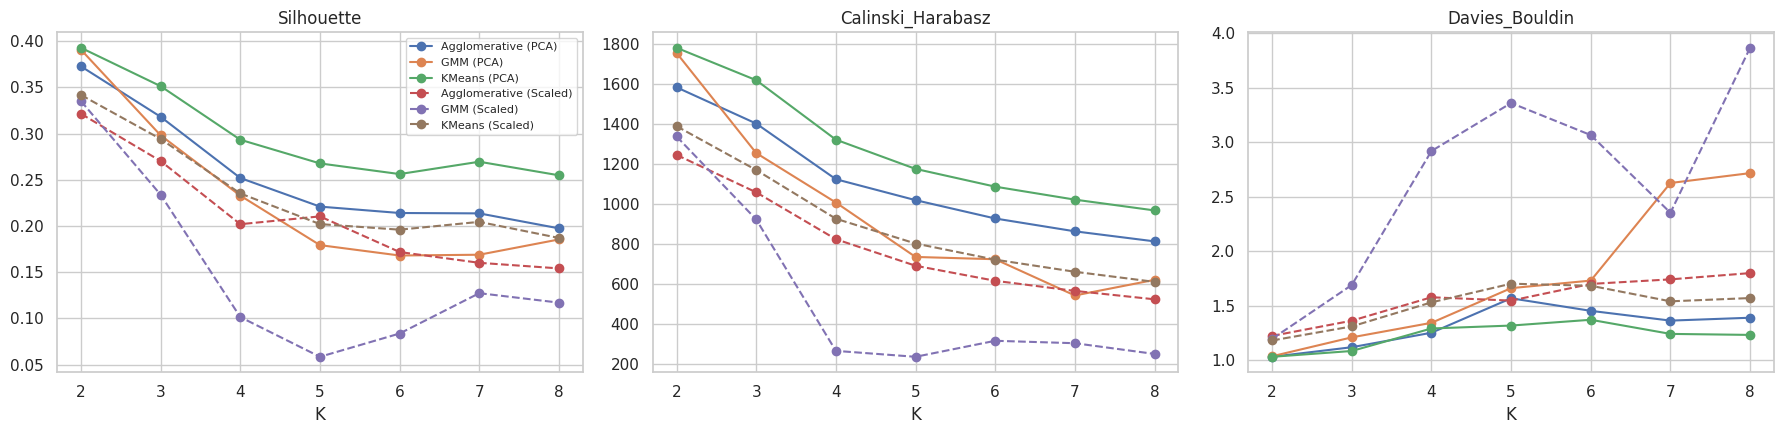

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, metric in zip(axes, ["Silhouette", "Calinski_Harabasz", "Davies_Bouldin"]):
    for (data_name, model_name), g in results.groupby(["Data", "Model"]):
        ax.plot(g["K"], g[metric], marker="o", ls="-" if data_name == "PCA" else "--", label=f"{model_name} ({data_name})")
    ax.set_title(metric); ax.set_xlabel("K")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

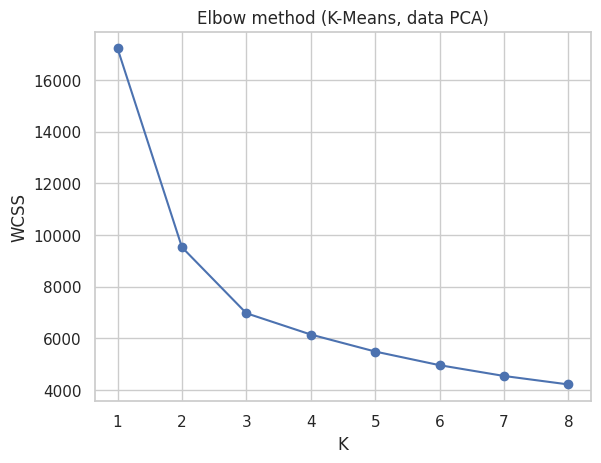

In [16]:
inertia = [KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_pca).inertia_ for k in range(1, 9)]
plt.plot(range(1, 9), inertia, marker="o")
plt.xlabel("K"); plt.ylabel("WCSS")
plt.title("Elbow method (K-Means, data PCA)")
plt.show()

### DBSCAN

DBSCAN membentuk cluster berdasarkan kepadatan dan menandai titik yang jarang sebagai *noise* (label −1). Parameter `eps` dipilih dari grafik *k-distance* (jarak ke tetangga ke-`min_samples`), di sekitar titik tekuk.

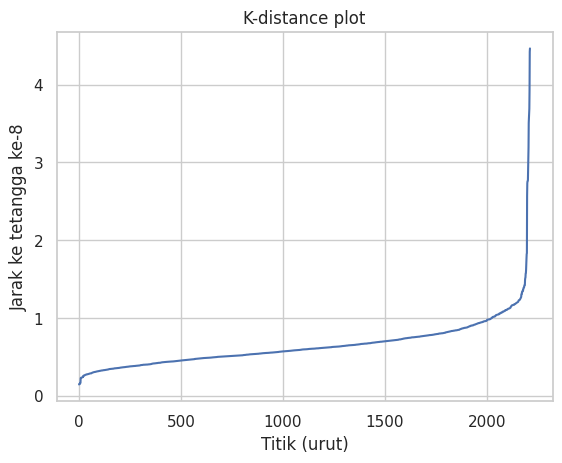

,eps,Jumlah_Cluster,Noise,Silhouette_tanpa_noise
0,0.5,22,1118,0.057
1,0.6,11,637,-0.083
2,0.7,2,356,0.037
3,0.8,2,203,0.126
4,1.0,1,60,NaN
5,1.2,1,21,NaN


In [17]:
min_samples = 2 * X_pca.shape[1]
dist = NearestNeighbors(n_neighbors=min_samples).fit(X_pca).kneighbors(X_pca)[0][:, -1]
plt.plot(np.sort(dist))
plt.xlabel("Titik (urut)"); plt.ylabel(f"Jarak ke tetangga ke-{min_samples}")
plt.title("K-distance plot")
plt.show()

dbscan_rows = []
for eps in [0.5, 0.6, 0.7, 0.8, 1.0, 1.2]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    n_clusters = len(set(labels) - {-1})
    mask = labels != -1
    sil = silhouette_score(X_pca[mask], labels[mask]) if n_clusters > 1 else np.nan
    dbscan_rows.append({"eps": eps, "Jumlah_Cluster": n_clusters, "Noise": (labels == -1).sum(), "Silhouette_tanpa_noise": sil})
pd.DataFrame(dbscan_rows).round(3)

- `eps` 0.5–0.6: data terpecah menjadi belasan hingga puluhan cluster kecil dan sebagian besar titik dianggap *noise*.
- `eps` 0.7–0.8: terbentuk 2 cluster, tetapi Silhouette sangat rendah (≤ 0.13).
- `eps` ≥ 1.0: hampir semua pelanggan masuk ke **satu cluster**.
- Artinya data pelanggan tidak membentuk kelompok padat yang terpisah jelas, melainkan tersebar kontinu. DBSCAN tidak cocok untuk data ini, jadi tidak dilanjutkan.

## 7. Pemilihan Model & Uji Stabilitas

In [18]:
best_per_k = results.loc[results.groupby("K")["Silhouette"].idxmax()]
best_per_k.round(3)

,Data,Model,K,Silhouette,Calinski_Harabasz,Davies_Bouldin,Cluster_Terkecil
21,PCA,KMeans,2,0.393,1783.418,1.033,1026
22,PCA,KMeans,3,0.351,1621.066,1.087,645
23,PCA,KMeans,4,0.293,1323.149,1.293,363
24,PCA,KMeans,5,0.268,1176.752,1.320,339
25,PCA,KMeans,6,0.256,1087.741,1.373,279
26,PCA,KMeans,7,0.270,1022.757,1.243,238
27,PCA,KMeans,8,0.255,968.668,1.234,215


**Pengamatan dari skenario:**
1. **Data PCA konsisten lebih baik daripada data Scaled** di semua model. Contoh K-Means K=3: Silhouette 0.351 (PCA) vs 0.294 (Scaled). PCA menggabungkan fitur yang saling berkorelasi sehingga noise berkurang.
2. **K-Means unggul dibanding Agglomerative dan GMM** di hampir semua nilai K. GMM pada data Scaled tidak stabil untuk K ≥ 4 (muncul cluster yang sangat kecil dan metriknya jatuh).
3. **K=2 punya metrik terbaik** (Silhouette 0.393), tetapi hanya memisahkan pelanggan menjadi dua kelompok besar sehingga terlalu kasar untuk strategi marketing.
4. **K=3 hanya turun sedikit** (Silhouette 0.351, Davies-Bouldin 1.087) dan memunculkan kelompok menengah dengan perilaku yang berbeda. Mulai K=4, metrik turun lebih tajam dan elbow sudah melandai.

**Model terpilih: K-Means, data PCA, K = 3.**

In [19]:
FINAL_K = 3
final_model = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
df["Cluster"] = final_model.fit_predict(X_pca)

print(results.query("Data == 'PCA' and Model == 'KMeans' and K == @FINAL_K").round(3).to_string(index=False))
df["Cluster"].value_counts().sort_index()

Data  Model  K  Silhouette  Calinski_Harabasz  Davies_Bouldin  Cluster_Terkecil
 PCA KMeans  3       0.351           1621.066           1.087               645


,count
Cluster,
0,645
1,878
2,689


**Uji stabilitas.** Model dilatih ulang dengan beberapa `random_state` berbeda, lalu labelnya dibandingkan dengan model final menggunakan *Adjusted Rand Index* (ARI). ARI = 1 berarti pembagian cluster identik (urutan nomor label tidak berpengaruh).

In [20]:
for seed in [0, 7, 21, 100, 2024]:
    labels = KMeans(n_clusters=FINAL_K, n_init=20, random_state=seed).fit_predict(X_pca)
    print(f"seed={seed:>4} | ARI={adjusted_rand_score(df['Cluster'], labels):.3f}")

seed=   0 | ARI=1.000
seed=   7 | ARI=0.999
seed=  21 | ARI=0.997
seed= 100 | ARI=1.000
seed=2024 | ARI=1.000


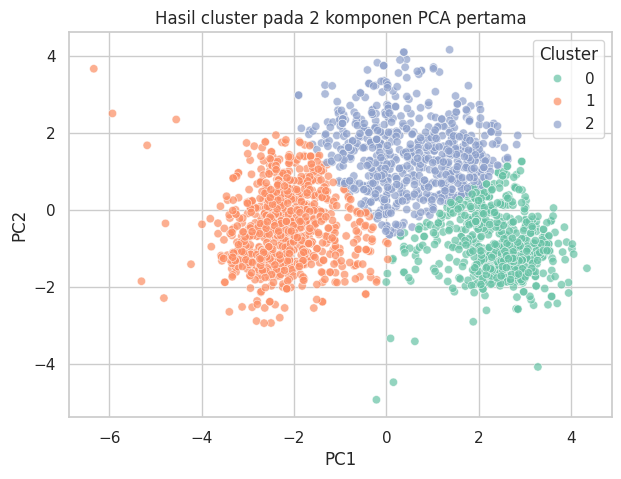

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["Cluster"], palette="Set2", alpha=0.7, ax=ax)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Hasil cluster pada 2 komponen PCA pertama")
plt.show()

## 8. Profiling Cluster

In [22]:
profile_cols = ["Income", "Age", "Spent", "Purchases", "Children", "Family_Size", "Is_Parent",
                "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
                "NumWebVisitsMonth", "Recency", "Total_Promos", "Response"]
profile = df.groupby("Cluster")[profile_cols].mean().round(2)
profile.insert(0, "Jumlah", df["Cluster"].value_counts().sort_index())
profile.T

Cluster,0,1,2
Jumlah,645.00,878.00,689.00
Income,75204.58,32246.61,55317.01
Age,46.00,41.82,48.40
Spent,1255.76,70.57,684.12
Purchases,18.87,5.20,16.06
Children,0.24,1.23,1.25
Family_Size,1.87,2.88,2.91
Is_Parent,0.24,0.88,0.95
NumDealsPurchases,1.17,1.85,4.00
NumWebPurchases,4.98,1.83,6.13


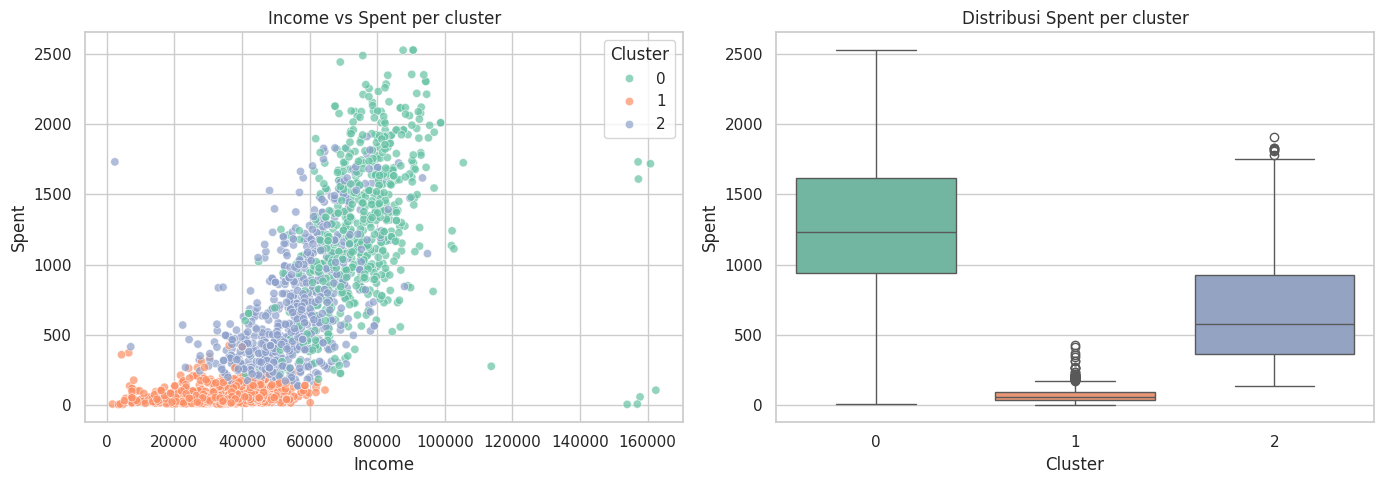

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Income", y="Spent", hue="Cluster", palette="Set2", alpha=0.7, ax=axes[0])
axes[0].set_title("Income vs Spent per cluster")
sns.boxplot(data=df, x="Cluster", y="Spent", palette="Set2", ax=axes[1])
axes[1].set_title("Distribusi Spent per cluster")
plt.tight_layout()
plt.show()

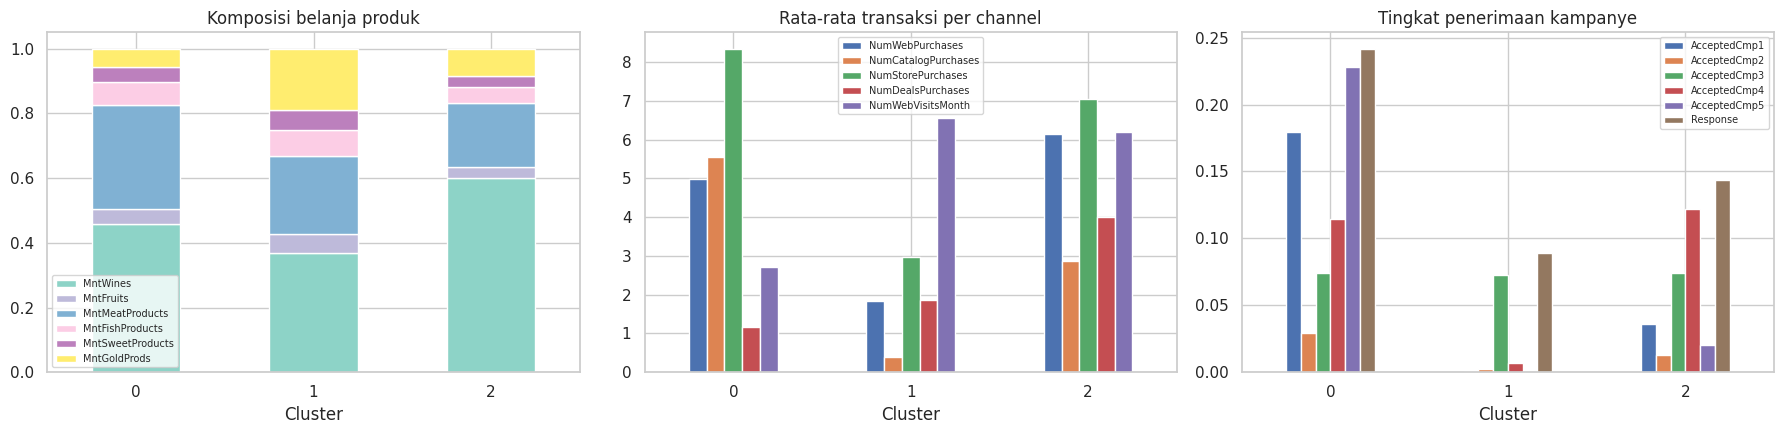

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

prod_share = df.groupby("Cluster")[products].sum()
prod_share.div(prod_share.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=axes[0], colormap="Set3")
axes[0].set_title("Komposisi belanja produk"); axes[0].legend(fontsize=7)

df.groupby("Cluster")[channels + ["NumDealsPurchases", "NumWebVisitsMonth"]].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Rata-rata transaksi per channel"); axes[1].legend(fontsize=7)

df.groupby("Cluster")[campaigns + ["Response"]].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Tingkat penerimaan kampanye"); axes[2].legend(fontsize=7)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

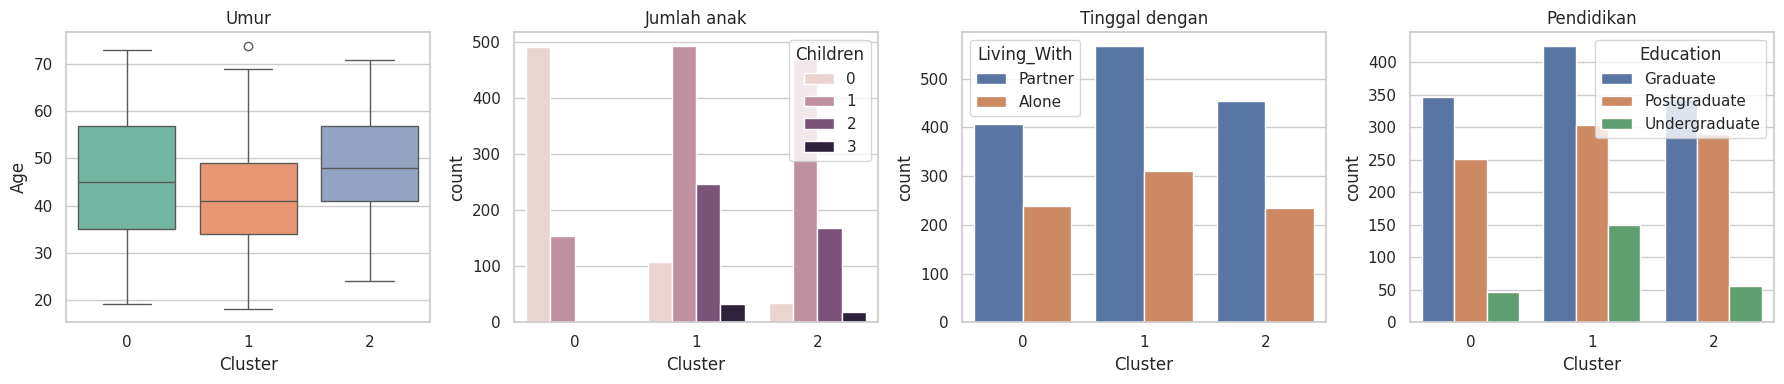

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.boxplot(data=df, x="Cluster", y="Age", palette="Set2", ax=axes[0])
sns.countplot(data=df, x="Cluster", hue="Children", ax=axes[1])
sns.countplot(data=df, x="Cluster", hue="Living_With", ax=axes[2])
sns.countplot(data=df, x="Cluster", hue="Education", ax=axes[3])
for ax, title in zip(axes, ["Umur", "Jumlah anak", "Tinggal dengan", "Pendidikan"]):
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Ringkasan profil:**

| | Cluster 0 | Cluster 1 | Cluster 2 |
|---|---|---|---|
| Jumlah pelanggan | 645 (29%) | 878 (40%) | 689 (31%) |
| Rata-rata income | ~75 ribu | ~32 ribu | ~55 ribu |
| Rata-rata belanja | ~1.256 | ~71 | ~684 |
| Porsi dari total belanja | **60%** | 5% | 35% |
| Punya anak | 24% | 88% | 95% |
| Pembelian dengan diskon | 1.2 | 1.9 | **4.0** |
| Kunjungan web / bulan | 2.7 | **6.6** | 6.2 |
| Channel utama | Toko & katalog | Toko (sedikit) | Toko & web |
| Respons kampanye terakhir | **24%** | 9% | 14% |

Catatan lain:
- Wine mendominasi belanja semua cluster. Cluster 1 punya porsi produk emas (*gold*) yang relatif besar (19%).
- Pendidikan dan status tinggal (`Living_With`) proporsinya mirip di ketiga cluster, jadi keduanya **bukan pembeda** segmen.
- `Recency` hampir sama di ketiga cluster (~49 hari), sesuai keputusan untuk tidak memakainya sebagai fitur clustering.

## 9. Persona & Rekomendasi

### Cluster 0 — Pelanggan Premium
Berpendapatan tinggi, sebagian besar tanpa anak, belanja besar lewat toko dan katalog, jarang memakai diskon. Menyumbang 60% total pendapatan dan paling responsif terhadap kampanye.

**Rekomendasi:** program loyalitas/VIP, penawaran produk premium (wine, daging), katalog eksklusif. Prioritaskan segmen ini untuk kampanye baru. Diskon besar tidak diperlukan karena mereka tidak sensitif harga.

### Cluster 1 — Pelanggan Hemat
Kelompok terbesar, berpendapatan rendah, mayoritas punya anak, paling muda. Sering membuka website tetapi jarang membeli. Hampir tidak merespons kampanye.

**Rekomendasi:** fokus ke konversi website (voucher pembelian pertama, pengingat keranjang), paket produk kebutuhan keluarga dengan harga terjangkau. Kurangi biaya kampanye umum ke segmen ini karena tingkat penerimaannya rendah.

### Cluster 2 — Keluarga Pemburu Diskon
Berpendapatan menengah, hampir semuanya punya anak, belanja cukup besar, dan paling sering membeli saat ada diskon. Aktif belanja lewat web dan toko.

**Rekomendasi:** promo diskon dan bundling keluarga, flash sale online, promo wine dengan potongan harga. Segmen ini punya potensi naik ke level belanja Cluster 0 jika diberi insentif yang tepat.

## 10. Kesimpulan

- Data dibersihkan dari nilai kosong, kolom konstan, dan 4 baris anomali (umur > 110 tahun, income 666.666).
- Fitur baru (`Spent`, `Children`, `Family_Size`, dll.) membuat profil pelanggan lebih mudah dibaca. Fitur yang skewed di-*log transform*, lalu seluruh fitur di-*standardize* dan direduksi dengan PCA (4 komponen, ~86% variansi).
- Dari 4 model × 2 skenario data, **K-Means pada data PCA dengan K=3** memberi keseimbangan terbaik antara metrik (Silhouette 0.351) dan kemudahan interpretasi. Hasilnya stabil (ARI ≈ 1 untuk berbagai seed). DBSCAN tidak cocok karena data tidak punya kelompok padat yang terpisah.
- Tiga segmen yang terbentuk: **Premium**, **Hemat**, dan **Keluarga Pemburu Diskon**. Pembeda utamanya adalah income, total belanja, keberadaan anak, dan sensitivitas terhadap diskon.
- **Keterbatasan:** Silhouette 0.35 menunjukkan batas antar-cluster tidak terlalu tegas (pelanggan tersebar kontinu), dan data berasal dari 2012–2014 sehingga perlu diperbarui sebelum dipakai untuk keputusan bisnis saat ini.

## Simpan Model

In [27]:
import joblib

joblib.dump({
    "scaler": scaler,
    "pca": pca,
    "kmeans": final_model,
    "features": features,
    "log_cols": log_cols
}, "customer_segmentation_model.pkl")


['customer_segmentation_model.pkl']

In [28]:
from google.colab import files

files.download("customer_segmentation_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>